# ☀️ UNISOLAR — EDA Pipeline (Phân tích khám phá)
**Tuần tự:** Load → Phân tách chu kỳ (Decomposition) → Phát hiện bất thường (Anomaly) → Heatmap giờ×trạm → Kiểm tra múi giờ → DST & Gap → Tương quan/Đa cộng tuyến → **Explorer time-series tương tác (lọc theo site & giờ)**.

Mọi phân tích **key theo `site_id`** — không trộn dữ liệu giữa các trạm.

In [ ]:
# # Colab: !pip install pyarrow plotly ipywidgets statsmodels -q
# import pandas as pd, numpy as np
# import matplotlib.pyplot as plt, seaborn as sns
# import plotly.express as px, plotly.graph_objects as go
# from statsmodels.tsa.seasonal import seasonal_decompose
# import warnings; warnings.filterwarnings('ignore')
# sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(14,4.5)

# from google.colab import drive; drive.mount('/content/drive')
# PATH='/content/drive/MyDrive/ml_mart_base_data.csv'   # đổi path nếu cần
# df=pd.read_csv(PATH); df['timestamp']=pd.to_datetime(df['timestamp'])
# df['hour']=df['timestamp'].dt.hour
# TARGET='energy_generated_kwh'
# print(f'✅ {len(df):,} dòng | {df.site_id.nunique()} trạm | {df.timestamp.min()} → {df.timestamp.max()}')
# df.head(3)

## 1. Seasonal Decomposition — tách chu kỳ
Tách chuỗi 1 tuần (672 mốc) của trạm tiêu biểu thành **Observed / Trend / Seasonal / Residual** (period=96 = 1 ngày). Residual lớn = nghi bất thường.

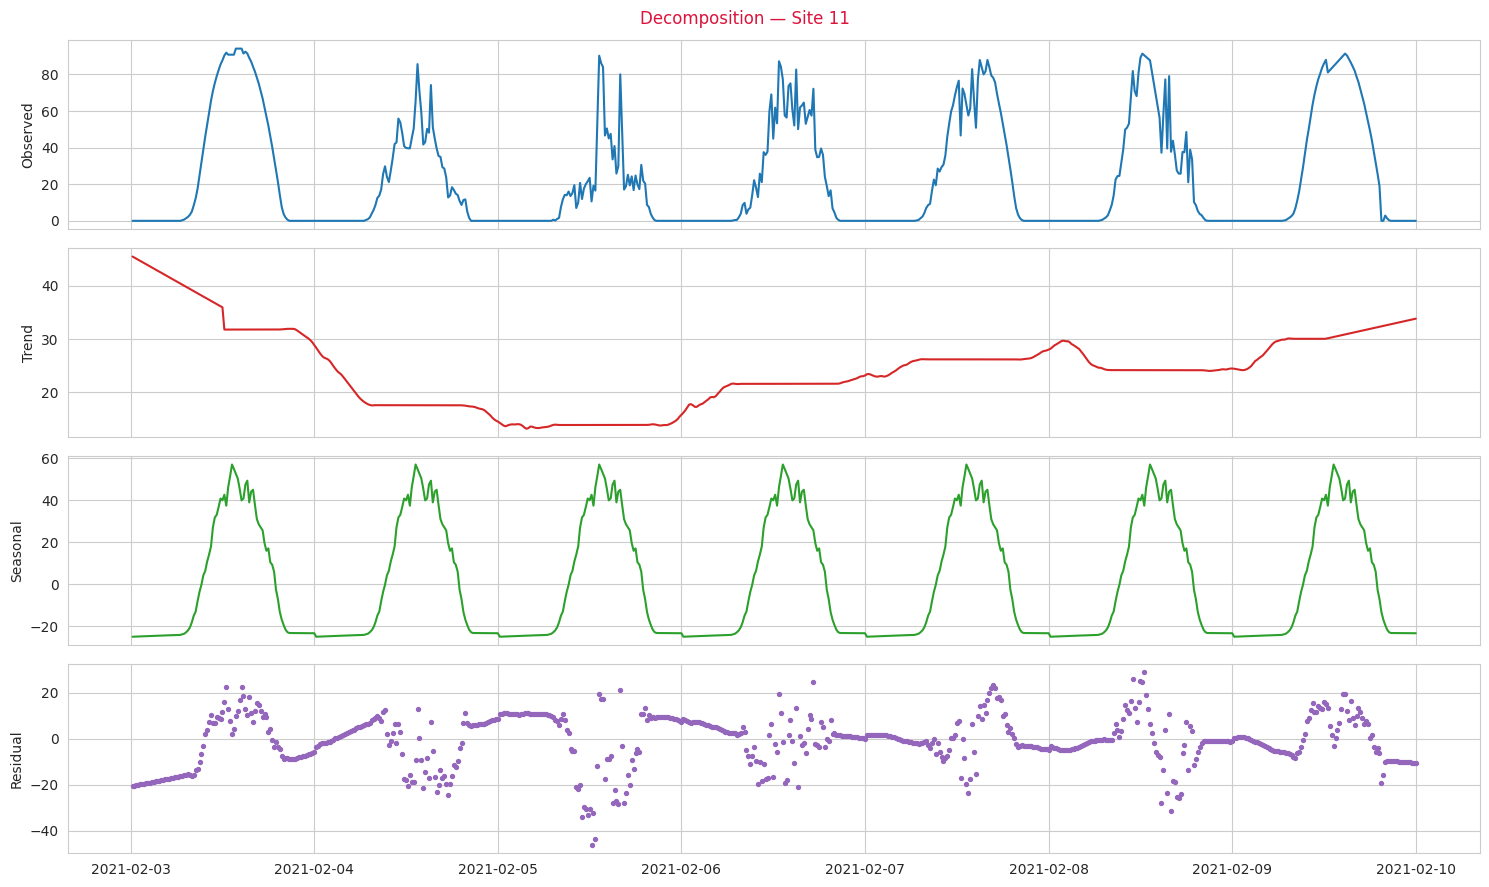

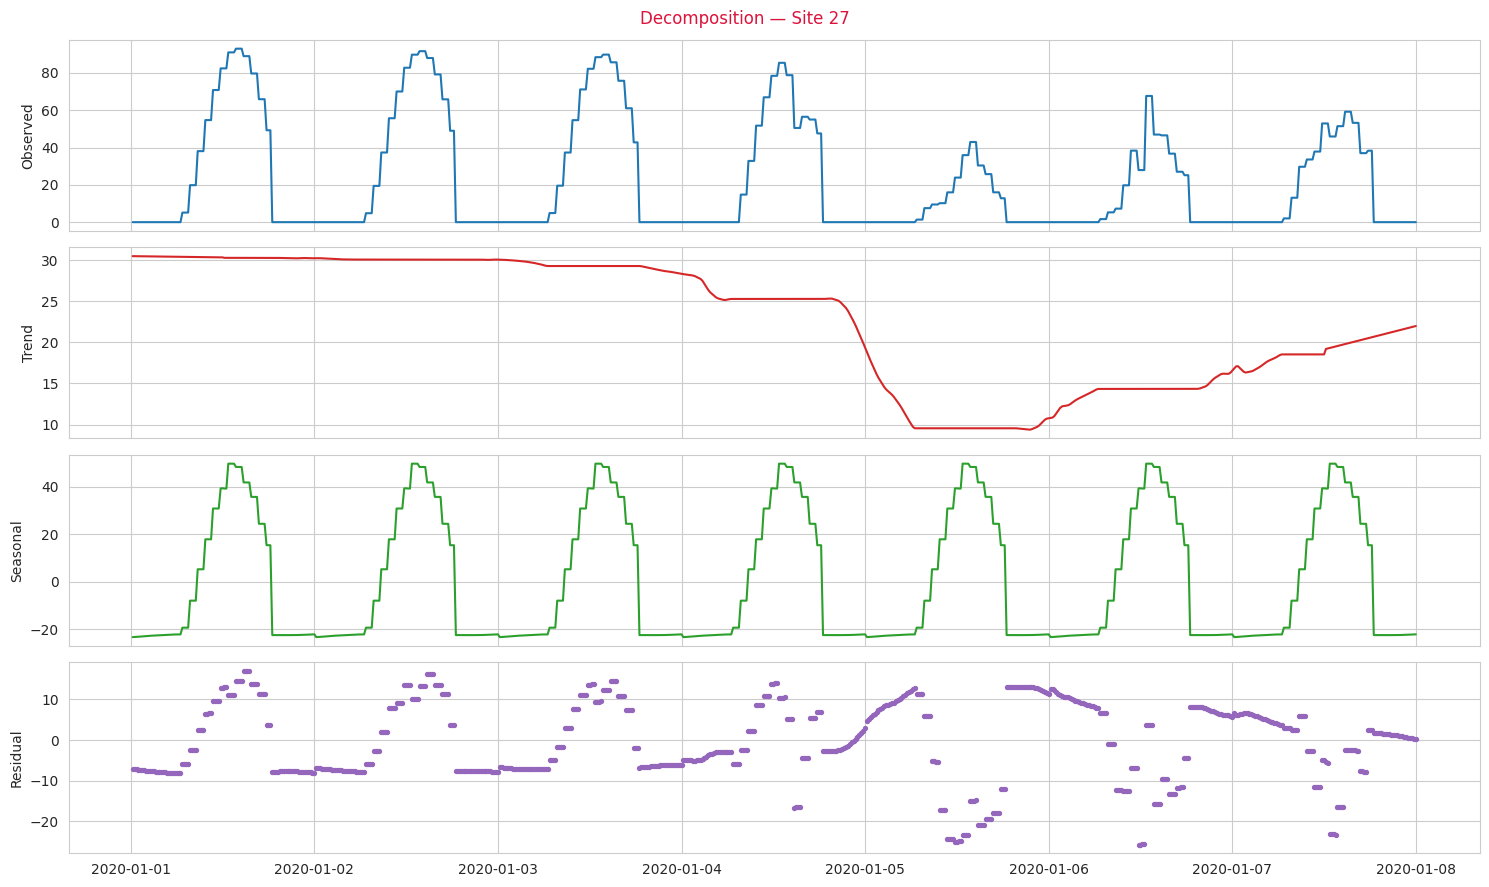

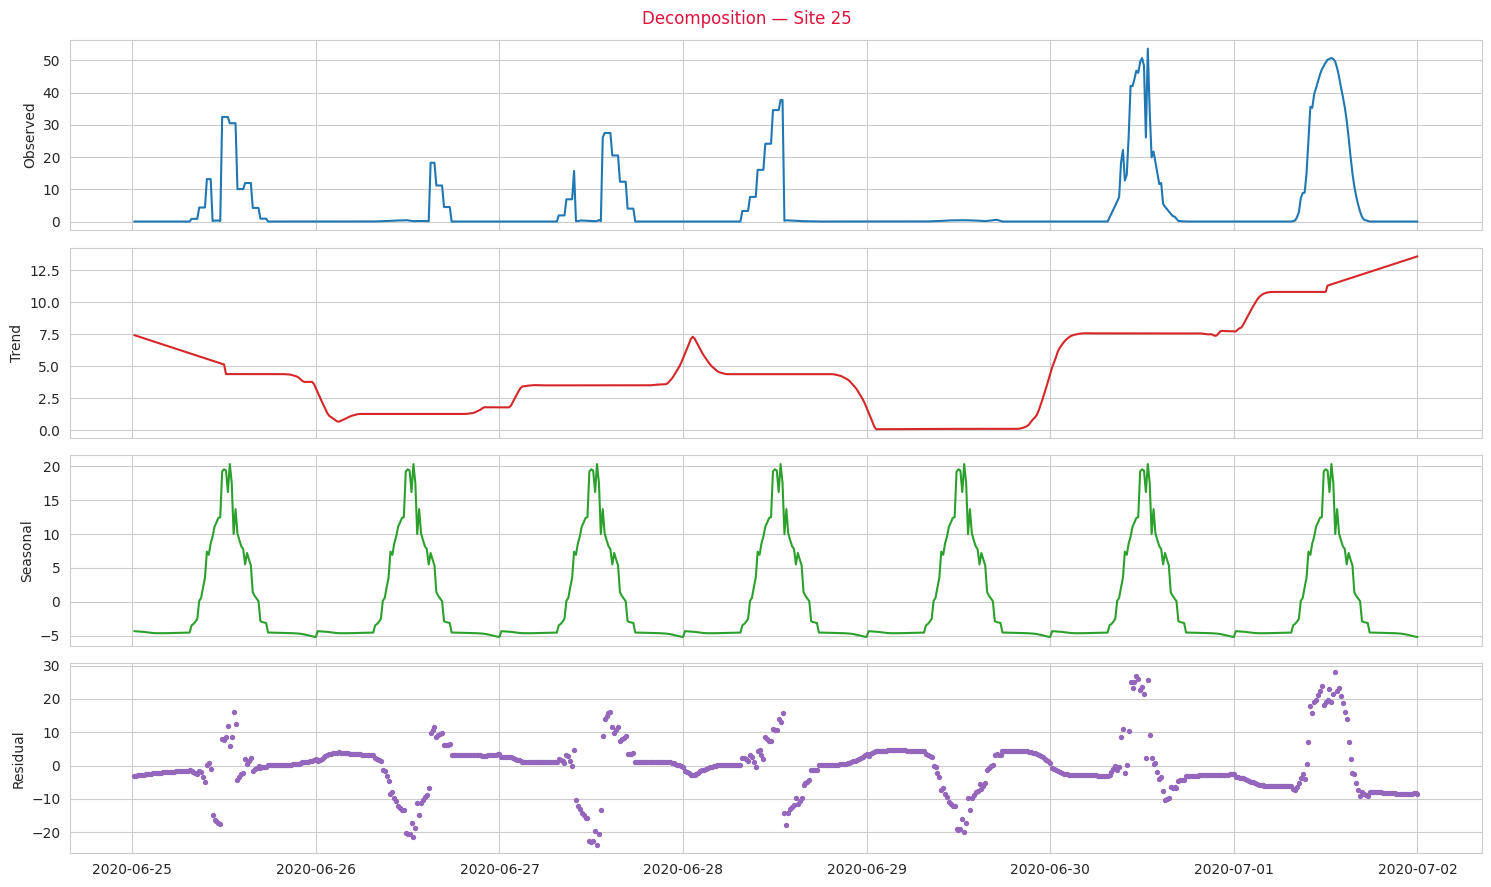

In [ ]:
for sid in [11, 27, 25]:                      # các trạm biến động mạnh
    s = (df[df.site_id==sid].sort_values('timestamp')
         .set_index('timestamp')[TARGET].head(672))
    if len(s) < 192: continue
    res = seasonal_decompose(s, model='additive', period=96, extrapolate_trend='freq')
    fig, ax = plt.subplots(4,1, figsize=(15,9), sharex=True)
    fig.suptitle(f'Decomposition — Site {sid}', color='crimson')
    ax[0].plot(res.observed, color='tab:blue');  ax[0].set_ylabel('Observed')
    ax[1].plot(res.trend, color='tab:red');      ax[1].set_ylabel('Trend')
    ax[2].plot(res.seasonal, color='tab:green'); ax[2].set_ylabel('Seasonal')
    ax[3].scatter(res.resid.index, res.resid, s=8, color='tab:purple'); ax[3].set_ylabel('Residual')
    plt.tight_layout(); plt.show()

## 2. Phát hiện bất thường (Anomaly / Fault)
Hai loại lỗi vật lý: **nắng to mà không điện** (inverter lỗi) và **đêm mà có điện** (nhiễu cảm biến).

⚠️ Nắng to-không điện (nghi inverter lỗi): 2,062 dòng
⚠️ Đêm-có điện (nhiễu cảm biến):           26,138 dòng

Top trạm lỗi "nắng-không điện":


,số điểm lỗi
site_id,
9,290
29,269
5,238
4,191
13,146
7,141
28,114
16,96


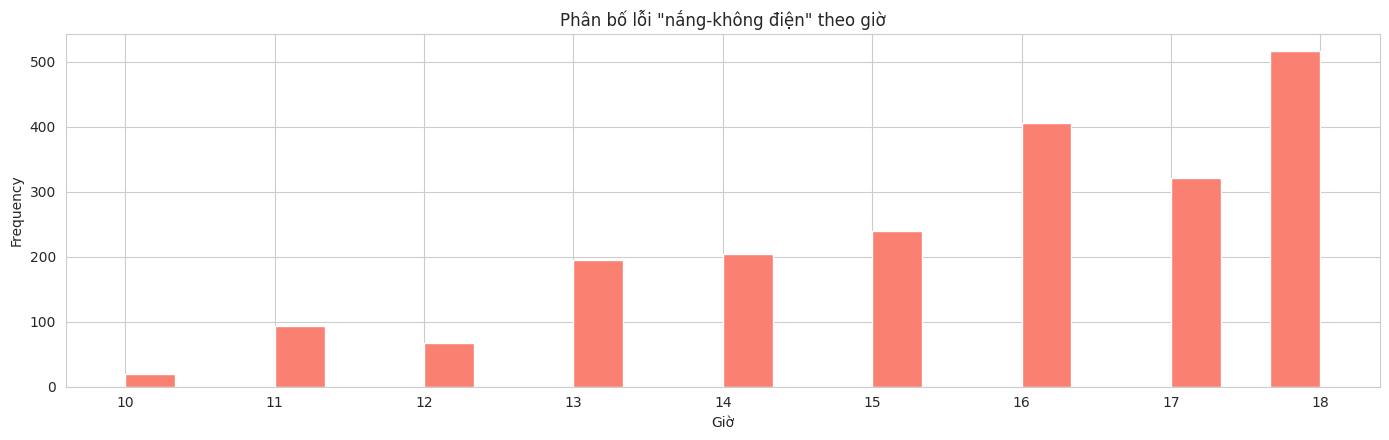

In [ ]:
fault_day   = df[(df['shortwave_radiation']>500) & (df[TARGET]<0.5)]   # nắng>500 nhưng điện<0.5
fault_night = df[(df['shortwave_radiation']==0) & (df[TARGET]>0.1)]      # đêm nhưng điện>0.1
print(f'⚠️ Nắng to-không điện (nghi inverter lỗi): {len(fault_day):,} dòng')
print(f'⚠️ Đêm-có điện (nhiễu cảm biến):           {len(fault_night):,} dòng')
print('\nTop trạm lỗi "nắng-không điện":')
display(fault_day['site_id'].value_counts().head(8).to_frame('số điểm lỗi'))

fault_day['hour'] = fault_day['timestamp'].dt.hour
fault_day['hour'].plot(kind='hist', bins=24, color='salmon')
plt.title('Phân bố lỗi "nắng-không điện" theo giờ'); plt.xlabel('Giờ'); plt.tight_layout(); plt.show()

## 3. Heatmap Giờ × Trạm — soi lỗi cảm biến biên (0h, 23h)

In [ ]:
piv = df.groupby(['site_id','hour'])[TARGET].mean().reset_index().pivot(
    index='site_id', columns='hour', values=TARGET)
fig = px.imshow(piv, aspect='auto',
    labels=dict(x='Giờ (0-23)', y='Site ID', color='kWh TB'),
    color_continuous_scale=[[0,'black'],[0.0001,'red'],[0.1,'orange'],[1,'yellow']],
    title='42 trạm × 24 giờ — vùng đen=0, đỏ=lỗi nhỏ, vàng=phát mạnh', template='plotly_dark')
fig.update_layout(height=900); fig.show()

## 4. Kiểm tra lệch múi giờ (Timezone shift)
Quét độ lệch giữa **bức xạ** và **sản lượng** (−12..+12 bước × 15'). Nếu đỉnh tương quan ở **shift 0** → khớp múi giờ, không lệch logic merge.

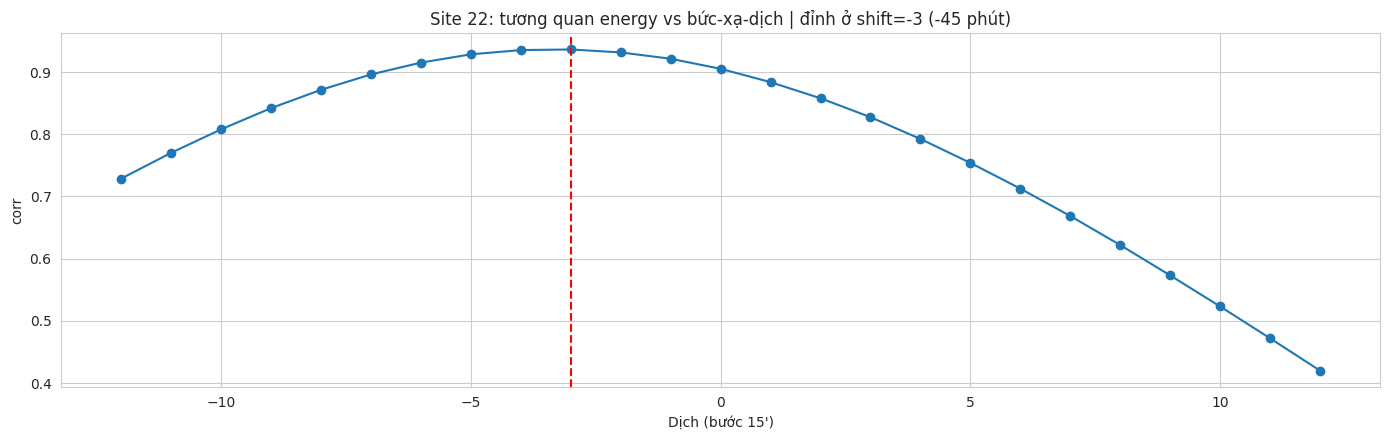

shift≈0 → múi giờ khớp. shift≠0 → bức xạ lệch pha với energy (cần căn lại lúc merge).


In [ ]:
sid = 22
s = df[df.site_id==sid].sort_values('timestamp')
shifts = range(-12, 13)
corrs = [s[TARGET].corr(s['shortwave_radiation'].shift(k)) for k in shifts]
best = shifts[int(np.argmax(corrs))]
plt.plot(list(shifts), corrs, '-o'); plt.axvline(best, color='r', ls='--')
plt.title(f'Site {sid}: tương quan energy vs bức-xạ-dịch | đỉnh ở shift={best} ({best*15} phút)')
plt.xlabel('Dịch (bước 15\')'); plt.ylabel('corr'); plt.tight_layout(); plt.show()
print('shift≈0 → múi giờ khớp. shift≠0 → bức xạ lệch pha với energy (cần căn lại lúc merge).')

In [ ]:
shifts = range(-12, 13)
shift_results = []

for sid in df.site_id.unique():
    s = df[df.site_id==sid].sort_values('timestamp')
    if len(s) == 0:  # Skip empty sites
        continue

    # Ensure shortwave_radiation column exists before proceeding
    if 'shortwave_radiation' not in s.columns or s['shortwave_radiation'].isnull().all():
        continue

    corrs = [s[TARGET].corr(s['shortwave_radiation'].shift(k)) for k in shifts]
    # Handle cases where all correlations might be NaN (e.g., due to constant values or missing data)
    if all(pd.isna(c) for c in corrs):
        best = None
    else:
        best_index = np.nanargmax(corrs)
        best = shifts[int(best_index)]
    shift_results.append({'site_id': sid, 'best_shift_steps': best, 'best_shift_minutes': best * 15 if best is not None else None})

shift_df = pd.DataFrame(shift_results)
print('Optimal shifts calculated for all sites:')
display(shift_df.head())

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(shift_df['best_shift_steps'].dropna(), bins=len(shifts), kde=False)
plt.title('Distribution of Optimal Time Shifts Across All Sites')
plt.xlabel('Optimal Shift (15-minute steps)')
plt.ylabel('Number of Sites')
plt.xticks(shifts)
plt.tight_layout()
plt.show()

## 5. DST & Lỗ hổng dữ liệu (Gap)

In [ ]:
# Trùng timestamp (fall-back DST)?
dup = df.duplicated(subset=['site_id','timestamp']).sum()
print(f'Số dòng trùng (site_id,timestamp) — fall-back DST: {dup}')

# Gap theo từng site: reindex lưới 15' rồi liệt kê khoảng trống dài nhất
rows=[]
for sid,g in df.groupby('site_id'):
    g=g.sort_values('timestamp')
    full=pd.date_range(g.timestamp.min(), g.timestamp.max(), freq='15min')
    miss=full.difference(g['timestamp'])
    rows.append({'site':sid,'coverage_%':round(100*(1-len(miss)/len(full)),2),'missing':len(miss)})
cov=pd.DataFrame(rows).sort_values('coverage_%')
print(f'Độ phủ TB: {cov["coverage_%"].mean():.2f}%')
print('5 trạm phủ thấp nhất:'); display(cov.head())

Số dòng trùng (site_id,timestamp) — fall-back DST: 0
Độ phủ TB: 98.13%
5 trạm phủ thấp nhất:


,site,coverage_%,missing
12,13,97.84,1704
0,1,97.90,1704
2,3,97.90,1704
1,2,97.90,1704
9,10,97.90,1704


## 6. Tương quan & Đa cộng tuyến
Tương quan thời tiết–sản lượng và **giữa các feature** (nguồn đa cộng tuyến — GHI/DNI/DHI phụ thuộc tuyến tính).

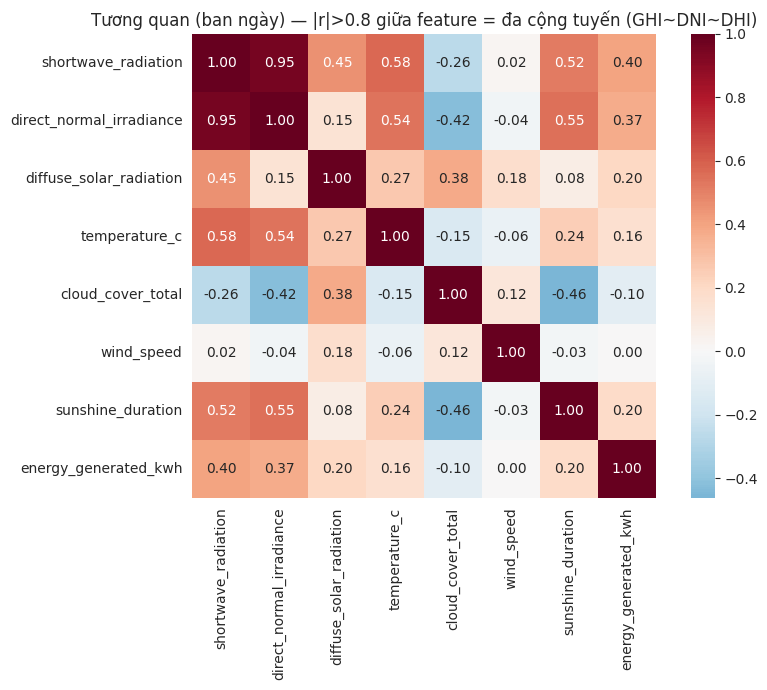

In [ ]:
WX=[c for c in ['shortwave_radiation','direct_normal_irradiance','diffuse_solar_radiation',
   'temperature_c','cloud_cover_total','wind_speed','sunshine_duration'] if c in df.columns]
day=df[df['shortwave_radiation']>10][WX+[TARGET]].dropna().sample(min(60000,len(df)), random_state=1)
plt.figure(figsize=(9,7))
sns.heatmap(day.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Tương quan (ban ngày) — |r|>0.8 giữa feature = đa cộng tuyến (GHI~DNI~DHI)')
plt.tight_layout(); plt.show()

## 7. ⭐ Explorer Time-Series tương tác — lọc theo Site & Giờ
Kéo-thả chọn **trạm**, **khoảng ngày**, và **khung giờ** để xem đường sản lượng vs bức xạ. (Dùng `ipywidgets`; nếu Colab không hiện widget, chạy ô kế bên dùng Plotly dropdown.)

In [ ]:
import ipywidgets as widgets
from IPython.display import display as disp
try:
    from google.colab import output; output.enable_custom_widget_manager()
except Exception: pass

sites = sorted(df.site_id.unique())
dmin, dmax = df.timestamp.min().date(), df.timestamp.max().date()

def explore(site_id, start, n_days, hour_lo, hour_hi):
    g = df[df.site_id==site_id].sort_values('timestamp')
    start = pd.Timestamp(start); end = start + pd.Timedelta(days=n_days)
    g = g[(g.timestamp>=start) & (g.timestamp<end)]
    g = g[(g.timestamp.dt.hour>=hour_lo) & (g.timestamp.dt.hour<=hour_hi)]
    fig, ax1 = plt.subplots(figsize=(15,4))
    ax1.plot(g.timestamp, g[TARGET], color='#264653', lw=1.5, label='Sản lượng (kWh)')
    ax1.set_ylabel('kWh', color='#264653')
    ax1.legend(loc='upper left') # Add legend to ax1
    ax2 = ax1.twinx()
    ax2.plot(g.timestamp, g['shortwave_radiation'], color='#e76f51', lw=1, alpha=.7, label='Bức xạ')
    ax2.set_ylabel('Bức xạ', color='#e76f51')
    ax2.legend(loc='upper right') # Add legend to ax2
    ax1.set_title(f'Site {site_id} | {start.date()} +{n_days} ngày | giờ {hour_lo}-{hour_hi}')
    plt.tight_layout(); plt.show()

widgets.interact(
    explore,
    site_id=widgets.Dropdown(options=sites, value=sites[0], description='Trạm'),
    start=widgets.DatePicker(value=pd.Timestamp(dmax)-pd.Timedelta(days=7), description='Từ ngày'),
    n_days=widgets.IntSlider(value=4, min=1, max=21, description='Số ngày'),
    hour_lo=widgets.IntSlider(value=0, min=0, max=23, description='Giờ từ'),
    hour_hi=widgets.IntSlider(value=23, min=0, max=23, description='Giờ đến'),
);

interactive(children=(Dropdown(description='Trạm', options=(np.int64(1), np.int64(2), np.int64(3), np.int64(4)…

In [ ]:
# Phương án 2 (Plotly): dropdown chọn trạm, tự có zoom/hover. Dùng nếu ipywidgets không hiện.
sample_days = 7
end = df.timestamp.max(); start = end - pd.Timedelta(days=sample_days)
sub = df[df.timestamp>=start]
fig = go.Figure()
for i, sid in enumerate(sorted(sub.site_id.unique())):
    g = sub[sub.site_id==sid].sort_values('timestamp')
    fig.add_trace(go.Scatter(x=g.timestamp, y=g[TARGET], name=f'Site {sid}',
                             visible=(i==0), mode='lines'))
buttons=[dict(label=f'Site {sid}', method='update',
              args=[{'visible':[j==i for j in range(len(sub.site_id.unique()))]}])
         for i,sid in enumerate(sorted(sub.site_id.unique()))]
fig.update_layout(title='Time-series tương tác (Plotly) — chọn trạm ở menu, kéo để zoom',
                  updatemenus=[dict(buttons=buttons, x=1.15, y=1)],
                  xaxis_title='Thời gian', yaxis_title='kWh', height=450)
fig.show()

*Hết EDA. Tiếp theo: notebook huấn luyện 3 thuật toán + Optuna.*